# Axe 1 : Vie personnelle 

Dans ce notebook, j'étudie les variables liées aux caractéristiques personnelles des employés afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes à l’axe
- de visualiser
- retenir seulement ce qui ressort clairement
---

## 1. Exploration des variables de l’axe
---

### 1.1 Import des librairies & chargement des données
---

In [1]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   string
 2   BusinessTravel            1470 non-null   string
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   string
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   string
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   string
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 1.2 Creation du DataFrame vie_perso
---
#### Colonnes incluses dans l'axe "Vie personnelle"

Cet axe regroupe les caractéristiques individuelles :
- âge  
- situation familiale  
- genre  
- niveau d'éducation  et domaines
- mobilité géographique  
donnant un contexte personnel pouvant influencer l'attrition.

In [3]:
# colonnes vie_perso
col_perso = ['Age', 'DistanceFromHome','Education','EducationField','Gender','MaritalStatus','NumCompaniesWorked']

# creation df_vie_perso
df_vie_perso = df_clean[col_perso + ['Attrition']].copy()
df_vie_perso.head()

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,Attrition
0,41,1,2,Life Sciences,Female,Single,8,Yes
1,49,8,1,Life Sciences,Male,Married,1,No
2,37,2,2,Other,Male,Single,6,Yes
3,33,3,4,Life Sciences,Female,Married,1,No
4,27,2,1,Medical,Male,Married,9,No


#### 1.2.1 Création des tranches d’âge

L'âge est une variable continue peu lisible en l'état.  
Pour faciliter l'analyse et observer des tendances plus nettes, je regroupe les employés en classes d'âge cohérentes du point de vue RH :

- **18–25 ans** : début de carrière, forte mobilité
- **26–35 ans** : stabilisation professionnelle, construction familiale
- **36–45 ans** : maturité professionnelle
- **46–55 ans** : employés expérimentés
- **55+ ans** : fin de carrière

Ces tranches permettront d'étudier plus clairement la relation entre âge et attrition.

In [4]:
# Creation tranche d'age
df_vie_perso["Tranche_Age"] = pd.cut(
    df_vie_perso["Age"],
    bins=[0 , 25, 35, 45, 55, 150],
    labels=["18-25", "26-35", "36-45", "46-55", "+55"],
    ordered=True,
    include_lowest=True
)

df_vie_perso["Tranche_Age"].value_counts()

Tranche_Age
26-35    606
36-45    468
46-55    226
18-25    123
+55       47
Name: count, dtype: int64

#### 1.2.2 Regroupement distance domicile–travail

Pour faciliter l'analyse exploratoire et rendre les visualisations plus lisibles, la distance est regroupée en tranches cohérentes :

- **1–5 km** : très proche  
- **6–10 km** : proche  
- **11–20 km** : distance moyenne  
- **> 20 km** : éloigné  

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre la distance domicile–travail et l’attrition.


In [5]:
# Creation des regroupement

df_vie_perso['Tranche_Distance'] = pd.cut(
    df_vie_perso['DistanceFromHome'],
    bins = [0, 5, 10, 20, 30],
    labels= ["1-5", "6-10", "11-20", ">20"],
    include_lowest=True,
    ordered=True
)

df_vie_perso["Tranche_Distance"].value_counts()

Tranche_Distance
1-5      632
6-10     394
11-20    240
>20      204
Name: count, dtype: int64

#### 1.2.3 Renommage des niveaux d’éducation

Les niveaux d’éducation sont initialement codés sous forme numérique (1 à 4).Pour faciliter la lecture et l’analyse, je remplace ces codes par des catégories explicites 
Cette transformation permet d’interpréter facilement la répartition des employés selon leur niveau d’étude.


In [6]:
niveau_education = {
    1 : 'Below College',
    2 : 'College',
    3 : 'Bachelor',
    4 : 'Master',
    5 : 'Doctor'
    }

df_vie_perso["NiveauEducation"] = df_vie_perso['Education'].replace(niveau_education)
df_vie_perso.head()

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,Attrition,Tranche_Age,Tranche_Distance,NiveauEducation
0,41,1,2,Life Sciences,Female,Single,8,Yes,36-45,1-5,College
1,49,8,1,Life Sciences,Male,Married,1,No,46-55,6-10,Below College
2,37,2,2,Other,Male,Single,6,Yes,36-45,1-5,College
3,33,3,4,Life Sciences,Female,Married,1,No,26-35,1-5,Master
4,27,2,1,Medical,Male,Married,9,No,26-35,1-5,Below College


#### 1.2.4 Renommage des genres
La variable `Gender` utilise des codes bruts (`Male`, `Female`).  
Je les remplace par des libellés plus explicites (*Homme* et *Femme*) afin d'améliorer la lisibilité et la cohérence du jeu de données.

In [7]:
df_vie_perso["Gender"] = df_vie_perso["Gender"].replace({
    "Male": "Homme",
    "Female": "Femme"
})
df_vie_perso.head()

,Age,DistanceFromHome,Education,EducationField,Gender,MaritalStatus,NumCompaniesWorked,Attrition,Tranche_Age,Tranche_Distance,NiveauEducation
0,41,1,2,Life Sciences,Femme,Single,8,Yes,36-45,1-5,College
1,49,8,1,Life Sciences,Homme,Married,1,No,46-55,6-10,Below College
2,37,2,2,Other,Homme,Single,6,Yes,36-45,1-5,College
3,33,3,4,Life Sciences,Femme,Married,1,No,26-35,1-5,Master
4,27,2,1,Medical,Homme,Married,9,No,26-35,1-5,Below College


#### 1.2.5 Regroupement du nombre d’entreprises précédemment travaillées

Pour faciliter l’analyse exploratoire et rendre les visualisations plus lisibles, le nombre d’entreprises précédemment travaillées est regroupé en tranches cohérentes :

- **0–1 entreprise** : employés très stables ou débutants  
- **2–3 entreprises** : employés ayant une mobilité modérée  
- **4–6 entreprises** : employés ayant une mobilité élevée  
- **7+ entreprises** : employés ayant une forte instabilité ou une carrière très variée  

Ces catégories permettent d’identifier plus facilement d’éventuelles relations entre le nombre d’entreprises précédemment travaillées et l’attrition.


In [8]:
df_vie_perso['Tranche_EtsTravaille'] = pd.cut(
    df_vie_perso['NumCompaniesWorked'],
    bins= [0, 1, 3, 6, 10],
    labels= ["0-1", "2-3", "4-6", "+7"],
    ordered=True,
    include_lowest=True
)

df_vie_perso["Tranche_EtsTravaille"].value_counts()

Tranche_EtsTravaille
0-1    718
2-3    305
4-6    272
+7     175
Name: count, dtype: int64

#### 1.3.2 Sauvegarde du DataFrame
---

In [ ]:
df_vie_perso.to_parquet(
    "C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/df_vie_perso.parquet",
    index=False)


### 1.3  Analyse individuelle des variables 
---
Dans cette section, j’analyse plusieurs caractéristiques personnelles des employés afin de mieux comprendre la composition de la population étudiée.  
Les variables sont analysées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.


#### 1.3.1 Tranche d’âge 
---
Je trie les tranches d’âge selon leur fréquence afin d’identifier rapidement les groupes les plus représentés au sein de l’entreprise et préparer l’analyse exploratoire.


##### Tableau des proportions

In [10]:

age = df_vie_perso["Tranche_Age"].value_counts(normalize=True).sort_values(ascending=False)*100

df_age = age.reset_index()
df_age.columns = ["Tranche_Age" , 'Pourcentage']
df_age

,Tranche_Age,Pourcentage
0,26-35,41.224490
1,36-45,31.836735
2,46-55,15.374150
3,18-25,8.367347
4,+55,3.197279


##### Histogramme des tranches d'âge

Ce graphique montre la répartition des employés selon les tranches d'âge.  
On observe deux groupes majoritaires :

- **26–35 ans**  
- **36–45 ans**

Ils représentent la majorité de la population active de l’entreprise.

Les tranches :

- **18–25 ans** et **46–55 ans** sont moins représentées,  
- tandis que les **55+** sont très minoritaires.


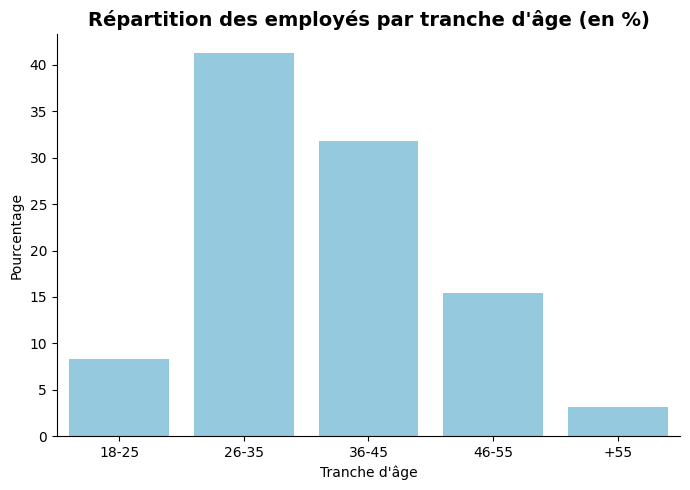

(None,)

In [11]:


plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines["right"].set_visible(False)

sns.barplot(data=df_age,y="Pourcentage", x="Tranche_Age",color="skyblue")
plt.xlabel("Tranche d'âge")
plt.ylabel("Pourcentage")
plt.title("Répartition des employés par tranche d'âge (en %)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show(),

Après avoir examiné la répartition par âge, je m’intéresse maintenant à la proximité des employés avec leur lieu de travail à travers la variable `DistanceFromHome`.

#### 1.3.2 DistanceFromHome
---
J’analyse ici la répartition des employés selon la distance entre leur domicile et le lieu de travail, afin d’identifier les niveaux de proximité les plus fréquents dans l’entreprise.


##### Tableau des proportions

In [12]:

distanceFromHome = df_vie_perso["Tranche_Distance"].value_counts(normalize=True).sort_values(ascending=False)*100

df_distanceFromHome = distanceFromHome.reset_index()
df_distanceFromHome.columns = ["Tranche_Distance", "Pourcentage"]

df_distanceFromHome

,Tranche_Distance,Pourcentage
0,1-5,42.993197
1,6-10,26.802721
2,11-20,16.326531
3,>20,13.877551


#### 

#### Répartition des employés par distance domicile–travail
On observe que les employés habitant très près ou relativement proches de leur lieu de travail représentent la majorité de l’effectif, 
avec près de 70 % situés à moins de 10 km.  
À l’inverse, les personnes résidant à plus de 20 km restent minoritaires (≈14 %).



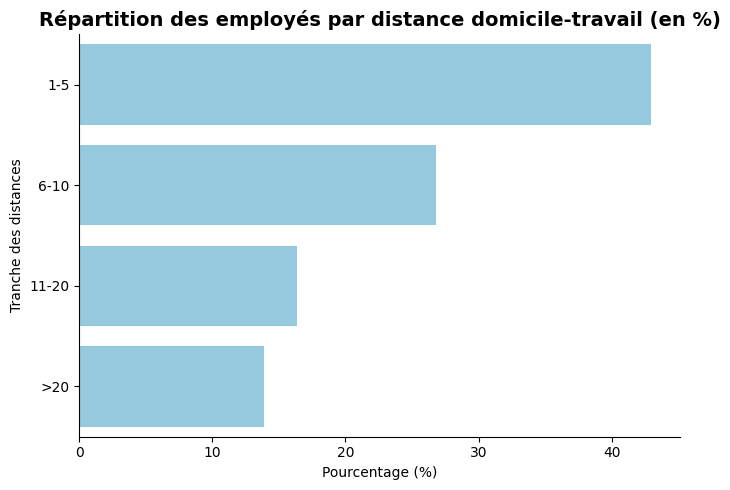

(None,)

In [13]:


plt.figure(figsize=(7,5))

sns.barplot(data=df_distanceFromHome, y="Tranche_Distance",x="Pourcentage",color="skyblue")

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

plt.xlabel("Pourcentage (%)")
plt.ylabel("Tranche des distances")
plt.title("Répartition des employés par distance domicile-travail (en %)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show(),

Une fois la distance domicile–travail analysée, j’explore maintenant la répartition des niveaux d’éducation au sein de l’entreprise.

#### 1.3.3 Niveau d’éducation
---
J’analyse ici la répartition des employés selon leur niveau d’éducation. Les niveaux codés dans le jeu de données sont convertis en catégories explicites afin de faciliter la lecture et l’interprétation.



##### Tableau des proportions

In [14]:

education = df_vie_perso['NiveauEducation'].value_counts(normalize=True).sort_values(ascending=False)*100

df_education = education.reset_index()
df_education.columns = ["Niveau d'Education", "Pourcentage"]

df_education

,Niveau d'Education,Pourcentage
0,Bachelor,38.911565
1,Master,27.074830
2,College,19.183673
3,Below College,11.564626
4,Doctor,3.265306


##### Répartition des employés par niveau d'education

On observe qu’un peu plus de la moitié des employés ont un niveau Bachelor (≈39 %) ou Master (≈27 %).  
Environ 30 % présentent un niveau College ou Below College, tandis qu’une minorité (≈3 %) ont atteint le niveau Doctorat.

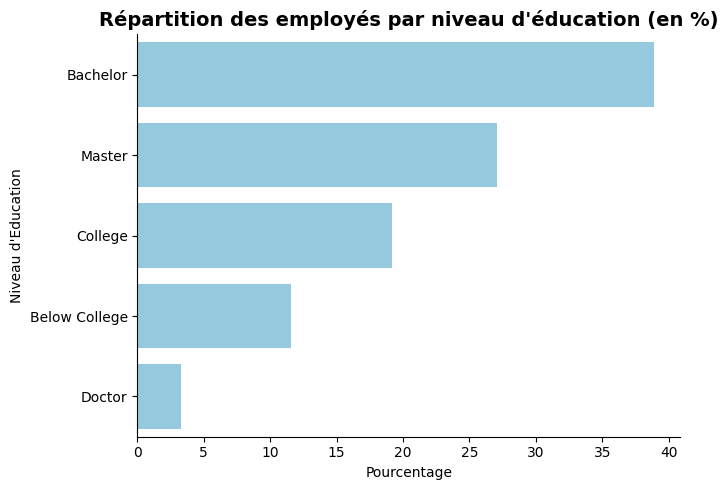

(None,)

In [15]:

plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_education, y="Niveau d'Education", x= "Pourcentage", color='skyblue')
plt.xlabel("Pourcentage")
plt.ylabel("Niveau d'Education")
plt.title("Répartition des employés par niveau d'éducation (en %)",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show(),

Après avoir exploré le niveau d’éducation des employés, j’analyse maintenant leur domaine d’étude à travers la variable `EducationField`.

#### 1.3.4 Domaine d’éducation (EducationField)
---

J’analyse ici la répartition des employés selon leur domaine d’éducation (`EducationField`).  
Cette variable permet d’identifier les disciplines académiques les plus représentées dans l’entreprise et d’observer la diversité des parcours.


##### Tableau des proportions

In [16]:
educationField = df_vie_perso["EducationField"].value_counts(normalize=True).sort_values(ascending=False)*100

df_EducationField = educationField.reset_index()
df_EducationField.columns =['Education Field', "Pourcentage"]

df_EducationField

,Education Field,Pourcentage
0,Life Sciences,41.22449
1,Medical,31.564626
2,Marketing,10.816327
3,Technical Degree,8.979592
4,Other,5.578231
5,Human Resources,1.836735


##### Repartitions des employes par domaine d'education

Ce graphique montre que deux domaines d’éducation sont particulièrement représentés :  
- **Life Sciences** (≈ 41 %)  
- **Medical** (≈ 32 %)  

Les domaines minoritaires sont **Other** (≈ 5 %) et **Human Resources** (≈ 2 %).

Cette exploration permet d’avoir une première vision des types de parcours académiques présents dans l’entreprise et d’apprécier la diversité des profils.

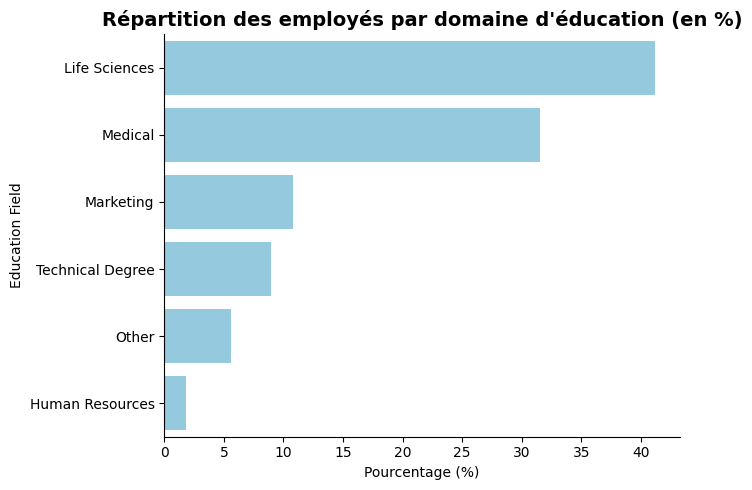

(None,)

In [17]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_EducationField, y= "Education Field", x= "Pourcentage", color="skyblue")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Education Field")
plt.title("Répartition des employés par domaine d'éducation (en %)",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show(),

Après l’analyse des domaines d’éducation, j’explore maintenant la répartition des employés selon leur genre.

#### 1.3.5 Genre
---
J’analyse ici la répartition des employés selon leur genre.  
Cette variable permet d’observer la composition de la population en termes de diversité et d’équilibre hommes–femmes.

##### Tableau des proportions

In [18]:
# Repartition par genre

genre = df_vie_perso["Gender"].value_counts(normalize=True).sort_values(ascending=False)*100
df_genre = genre.reset_index()

df_genre.columns = ["Genre", "Pourcentage"]
df_genre.reset_index()

df_genre

,Genre,Pourcentage
0,Homme,60.0
1,Femme,40.0


##### Repartition des employees par genre

La répartition hommes–femmes est relativement équilibrée dans l’entreprise, avec une légère majorité d'hommes représentant 60 % de l’effectif.


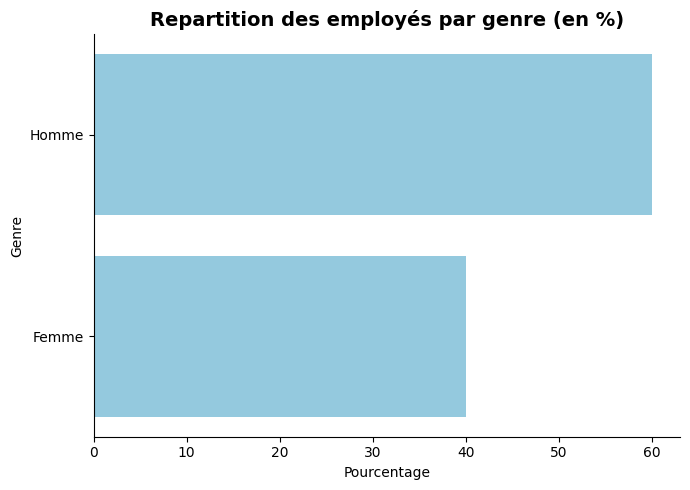

(None,)

In [19]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines["top"].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_genre, y= 'Genre', x= "Pourcentage", color="skyblue")
plt.xlabel("Pourcentage")
plt.ylabel('Genre')
plt.title("Repartition des employés par genre (en %)",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show(),

#### 

Après avoir examiné la répartition par genre, je m’intéresse maintenant au statut marital des employés à travers la variable `MaritalStatus`.

#### 1.3.6 Statut marital
---

J’analyse ici la répartition des employés selon leur statut marital, afin d’identifier les situations familiales les plus représentées dans l’entreprise.


##### Tableau des proportions

In [20]:
maritalStatus = df_vie_perso['MaritalStatus'].value_counts(normalize=True).sort_values(ascending=False)*100

df_MaritalStatus = maritalStatus.reset_index()
df_MaritalStatus.columns = ["Statut marital", "Pourcentage"]

df_MaritalStatus

,Statut marital,Pourcentage
0,Married,45.782313
1,Single,31.972789
2,Divorced,22.244898


##### Repartitions des employees selon leur statut marital

Ce graphique montre que le statut marital le plus représenté est **Married** (≈ 46 %).  
Le statut **Single** concerne environ 32 % des employés, tandis que **Divorced** représente près de 22 %.

Cette exploration permet d’obtenir une première vision des situations familiales présentes dans l’entreprise.

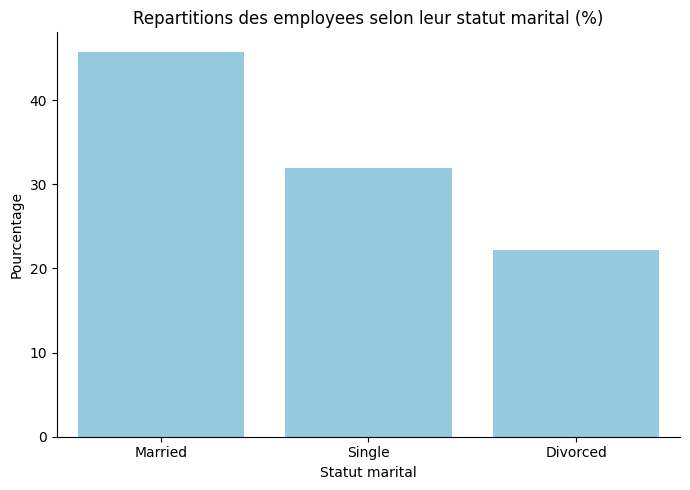

(None,)

In [21]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_MaritalStatus, y="Pourcentage", x="Statut marital", color="skyblue")
plt.xlabel("Statut marital")
plt.ylabel("Pourcentage")
plt.title("Repartitions des employees selon leur statut marital (%)")
plt.tight_layout()
plt.show(),

Une fois le statut marital analysé, j’explore maintenant la répartition du nombre d’entreprises dans lesquelles les employés ont travaillé auparavant.

#### 1.3.7 Répartition des employés selon le nombre d’entreprises précédemment travaillées

---
J’analyse ici la répartition des employés selon leur mobilité professionnelle passée.  
Cette variable permet d’observer le niveau de stabilité professionnelle des employés.

##### Tableau des proportions

In [22]:
numCompaniesWorked = df_vie_perso["Tranche_EtsTravaille"].value_counts(normalize=True).sort_values(ascending=False)*100

df_NumCompaniesWorked =numCompaniesWorked.reset_index()
df_NumCompaniesWorked.columns = ["Tranche_NbEntreprises", "Pourcentage"]

df_NumCompaniesWorked

,Tranche_NbEntreprises,Pourcentage
0,0-1,48.843537
1,2-3,20.748299
2,4-6,18.503401
3,+7,11.904762


##### Repartition des employes par le nombre d'entreprise travaillés précédemment

On observe que les employés présentant une mobilité professionnelle faible à modérée représentent la majorité de l’effectif, 
avec près de 65 % des employés ayant travaillé dans au plus trois entreprises.  

À l’inverse, les profils présentant une forte instabilité ou une carrière très variée restent minoritaires (≈14 %).

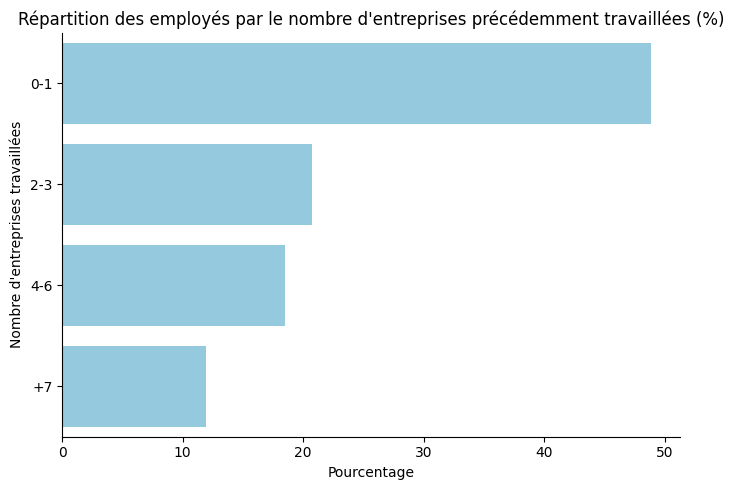

(None,)

In [23]:
plt.figure(figsize=(7,5))

axe = plt.gca()
axe.spines['top'].set_visible(False)
axe.spines['right'].set_visible(False)

sns.barplot(data=df_NumCompaniesWorked, x="Pourcentage", y="Tranche_NbEntreprises", color="skyblue")
plt.ylabel("Nombre d'entreprises travaillées")
plt.xlabel("Pourcentage")
plt.title("Répartition des employés par le nombre d'entreprises précédemment travaillées (%)")
plt.tight_layout()
plt.show(),

Cette analyse individuelle permet de mieux comprendre la composition de la population étudiée selon les caractéristiques personnelles.  
La section suivante s’intéresse désormais aux relations entre ces variables et l’attrition.

## 2. Attrition — Comparaisons simples
---

### 2.1 Introduction
---
Dans cette section, je compare la variable cible, l’attrition, aux variables personnelles analysées précédemment, afin d’identifier d’éventuelles relations entre ces caractéristiques et le départ des employés.


##### Tableau de proportions Attrition Yes / No

In [24]:
attrition = df_vie_perso['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100

df_attrition = attrition.reset_index()
df_attrition.columns = ['Attrition', "Pourcentage"]

df_attrition

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D’après ce tableau, le taux d’attrition global observé dans le jeu de données est d’environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l’accent est mis sur le taux d’attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 2.2 Analyse de l’attrition selon les variables personnelles
---
Les variables sont comparées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.  
Cette approche permet d’identifier des différences de comportement entre les groupes avant toute analyse approfondie.

#### 2.2.1 Attrition et tranche d’âge
---
Dans cette section, je compare l’attrition selon les tranches d’âge afin d’observer si le taux d’attrition varie en fonction de l’âge des employés.


##### Tableau de proportions


In [25]:
# Attrition par tranche d'age
df_age_attrition = df_vie_perso[["Tranche_Age","Attrition"]]
df_age_attrition = df_age_attrition.reset_index(drop=True)
df_age_attrition.head()

# Calcul groupe

age_attrition = df_age_attrition.groupby("Tranche_Age")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(2)*100
age_attrition = age_attrition.reset_index(name="Pourcentage")

display(age_attrition)

# Création d'une table pivot: lignes = Tranche_Age, colonnes = Attrition, valeur = Pourcentage
pivot_age_attrition = age_attrition.pivot(index="Tranche_Age",columns="Attrition", values="Pourcentage").fillna(0)
pivot_age_attrition



C:\Users\Kemu\AppData\Local\Temp\ipykernel_34504\3254526079.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df_age_attrition.groupby("Tranche_Age")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(2)*100


,Tranche_Age,Attrition,Pourcentage
0,36-45,No,91.0
1,46-55,No,88.0
2,+55,No,83.0
3,26-35,No,81.0
4,18-25,No,64.0
5,18-25,Yes,36.0
6,26-35,Yes,19.0
7,+55,Yes,17.0
8,46-55,Yes,12.0
9,36-45,Yes,9.0


Attrition,No,Yes
Tranche_Age,,
18-25,64.0,36.0
26-35,81.0,19.0
36-45,91.0,9.0
46-55,88.0,12.0
+55,83.0,17.0


##### Graphique — Analyse de la relation entre la tranche d’âge et l’attrition

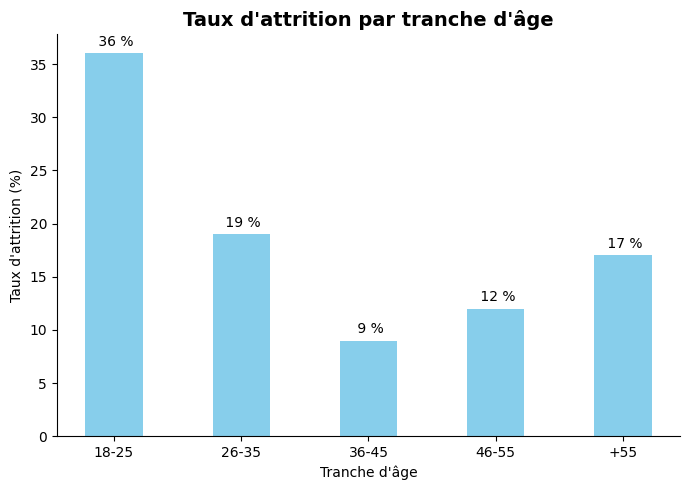

In [26]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(pivot_age_attrition.index))
y = pivot_age_attrition["Yes"]

# barplot
bars = ax.bar(x, y, color="skyblue", width=0.45)

# Pourcentage affiché

ax.bar_label(bars, labels=[f'{v : .0F} %' for v in y ], padding=3)

# axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_age_attrition.index)
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel("Taux d'attrition (%)")
ax.set_title("Taux d'attrition par tranche d'âge",fontweight="bold", fontsize=14)

fig.tight_layout()
plt.show()

##### Observation descriptive

On observe que le taux d’attrition varie selon l’âge.  
La tranche **18–25 ans** présente le taux d’attrition le plus élevé (≈36 %).  
À l’inverse, les tranches **36–45 ans** et **46–55 ans** affichent les taux les plus faibles (≈9 % et ≈12 %).  
Les tranches **26–35 ans** et **+55 ans** se situent à un niveau intermédiaire (≈19 % et ≈17 %).


Après avoir analysé la relation entre l’attrition et les tranches d’âge, je m’intéresse maintenant à une autre variable personnelle : la distance entre le domicile et le lieu de travail.

#### 2.2.2 Attrition et distance domicile–travail
---
Dans cette section, je compare l’attrition selon la distance entre le domicile et le lieu de travail afin d’observer si le taux d’attrition varie en fonction de l’éloignement.

##### Tableau de proportions ­­

In [27]:
df_distance_attrition = df_vie_perso[["Tranche_Distance","Attrition"]]
df_distance_attrition.reset_index()
df_distance_attrition.head()

# Calcul du groupe
distance_attrition = df_distance_attrition.groupby("Tranche_Distance")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
distance_attrition = distance_attrition.reset_index(name="Pourcentage")
display(distance_attrition)

# Création d'une table pivot: lignes = Tranche_Distance, colonnes = Attrition, valeur = Pourcentage
pivot_distance_attrition = distance_attrition.pivot(index="Tranche_Distance", columns="Attrition", values="Pourcentage").fillna(0)
pivot_distance_attrition

C:\Users\Kemu\AppData\Local\Temp\ipykernel_34504\4166980790.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_attrition = df_distance_attrition.groupby("Tranche_Distance")['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100


,Tranche_Distance,Attrition,Pourcentage
0,1-5,No,86.2
1,6-10,No,85.5
2,11-20,No,80.0
3,>20,No,77.9
4,>20,Yes,22.1
5,11-20,Yes,20.0
6,6-10,Yes,14.5
7,1-5,Yes,13.8


Attrition,No,Yes
Tranche_Distance,,
1-5,86.2,13.8
6-10,85.5,14.5
11-20,80.0,20.0
>20,77.9,22.1


##### Graphique — Analyse de la relation entre la distance domicile–travail et l’attrition

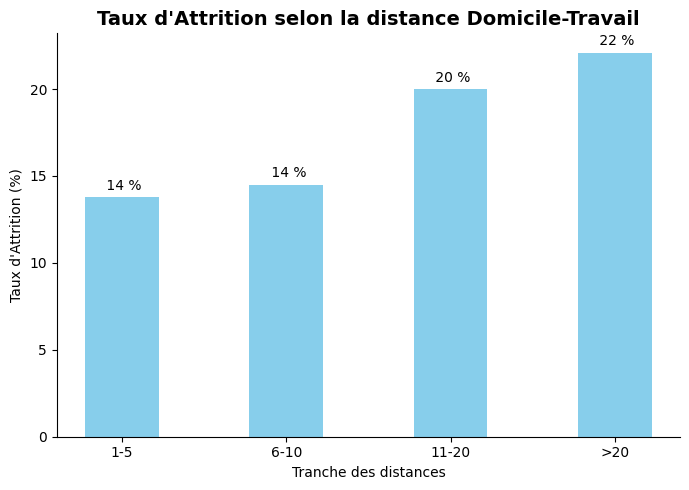

(None,)

In [28]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

# Donnée
x = np.arange(len(pivot_distance_attrition.index))
y = pivot_distance_attrition['Yes']

# Barplot
bars = ax.bar(x, y, color="Skyblue", width=0.45)

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .0F} %'for v in y], padding=3)

# axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_distance_attrition.index)
ax.set_xlabel("Tranche des distances")
ax.set_ylabel("Taux d'Attrition (%)")
ax.set_title("Taux d'Attrition selon la distance Domicile-Travail", fontweight="bold", fontsize=14)
fig.tight_layout()
plt.show(),

On observe que le taux d’attrition est plus faible pour les employés habitant à moins de 10 km de leur lieu de travail, avec des valeurs comprise entre **13 % et 15 %**.  

En revanche, le taux d’attrition augmente avec la distance : elle atteint environ **20 %** pour la tranche **11–20 km** et dépasse **22 %** au dela de 20 km.

Une fois la distance domicile et lieu de travail analysé, j'explore si l'attrition varie en fonction du niveau d'éducation des employés.

#### 2.2.3 Attrition et niveau d’éducation
---
Dans cette section, je compare l’attrition selon le niveau d’éducation afin d’observer si le taux d’attrition varie en fonction du niveau d’étude des employés.

##### Tableau de proportions

In [29]:
df_education_attrition = df_vie_perso[["NiveauEducation","Attrition"]]
df_education_attrition.reset_index()
df_education_attrition

# Calcul du groupe
education_attrition = df_education_attrition.groupby('NiveauEducation')['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
education_attrition = education_attrition.reset_index(name="Pourcentage")
display(education_attrition)


# Création d'une table pivot: lignes = NiveauEducation, colonnes = Attrition, valeur = Pourcentage
pivot_education_attrition = education_attrition.pivot(index="NiveauEducation", columns="Attrition", values="Pourcentage")
pivot_education_attrition = pivot_education_attrition.sort_values("Yes", ascending=False)
pivot_education_attrition

,NiveauEducation,Attrition,Pourcentage
0,Doctor,No,89.6
1,Master,No,85.4
2,College,No,84.4
3,Bachelor,No,82.7
4,Below College,No,81.8
5,Below College,Yes,18.2
6,Bachelor,Yes,17.3
7,College,Yes,15.6
8,Master,Yes,14.6
9,Doctor,Yes,10.4


Attrition,No,Yes
NiveauEducation,,
Below College,81.8,18.2
Bachelor,82.7,17.3
College,84.4,15.6
Master,85.4,14.6
Doctor,89.6,10.4


##### Graphique — Analyse de la relation entre le niveau d’éducation et l’attrition

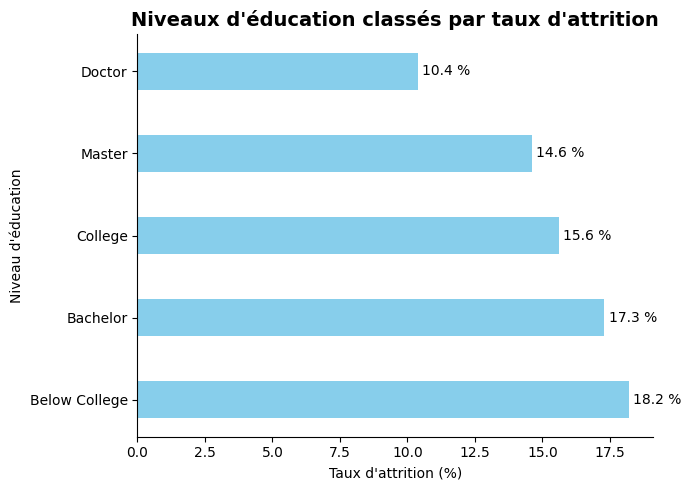

(None,)

In [30]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)

# Données
x = np.arange(len(pivot_education_attrition.index))
y = pivot_education_attrition["Yes"]

# Barplot
bars = ax.barh(x, y, color="Skyblue", height= 0.45)

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v :.1F} %'for v in y],padding=3)

# axes et labels
ax.set_yticks(x)
ax.set_yticklabels(pivot_education_attrition.index)
ax.set_ylabel("Niveau d'éducation")
ax.set_xlabel("Taux d'attrition (%)")
ax.set_title("Niveaux d'éducation classés par taux d'attrition", fontweight="bold", fontsize=14)

fig.tight_layout()
plt.show(),

On observe que le taux d’attrition varie selon le niveau d’éducation.  
Les niveaux **Below College** (≈18 %) et **Bachelor** (≈17 %) présentent les taux d’attrition les plus élevés.  

À l’inverse, le niveau **Doctor** affiche le taux d’attrition le plus faible (≈10 %).  
Les niveaux **College** et **Master** se situent à un niveau intermédiaire, avec un taux d’attrition d’environ **15 %**.

Après avoir analysé la relation entre l’attrition et le niveau d’éducation, je m’intéresse maintenant au domaine d’éducation des employés.

#### 2.2.4 Attrition et domaine d’éducation
---
Dans cette section, je compare l’attrition selon le domaine d’éducation afin d’observer si le taux d’attrition varie en fonction de la spécialité académique des employés.

##### Tableau de proportions

In [31]:
df_educationField_attrition = df_vie_perso[["EducationField", "Attrition"]]
df_educationField_attrition.reset_index()
df_educationField_attrition

# Calcul du groupe

educationfield_attrition = df_educationField_attrition.groupby("EducationField")["Attrition"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
educationfield_attrition  = educationfield_attrition .reset_index(name="Pourcentage")
display(educationfield_attrition) 

# Table pivot : ligne = EducationField , colonnes = attrition, values = Pourcentage

pivot_educationfield_attrition  = educationfield_attrition .pivot(index= "EducationField", columns= "Attrition", values= "Pourcentage")
pivot_educationfield_attrition  = pivot_educationfield_attrition .sort_values("Yes", ascending=False)
pivot_educationfield_attrition 

,EducationField,Attrition,Pourcentage
0,Other,No,86.6
1,Medical,No,86.4
2,Life Sciences,No,85.3
3,Marketing,No,78.0
4,Technical Degree,No,75.8
5,Human Resources,No,74.1
6,Human Resources,Yes,25.9
7,Technical Degree,Yes,24.2
8,Marketing,Yes,22.0
9,Life Sciences,Yes,14.7


Attrition,No,Yes
EducationField,,
Human Resources,74.1,25.9
Technical Degree,75.8,24.2
Marketing,78.0,22.0
Life Sciences,85.3,14.7
Medical,86.4,13.6
Other,86.6,13.4


##### Graphique — Analyse de la relation entre le domaine d’éducation et l’attrition

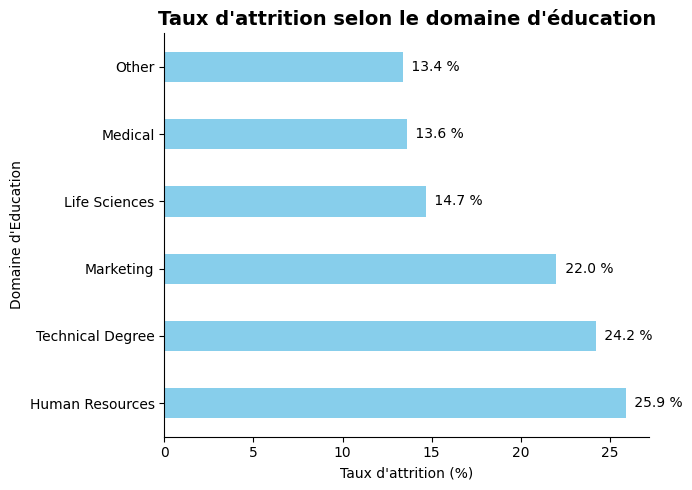

(None,)

In [32]:
fig , ax = plt.subplots(figsize=(7, 5))

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)

# Données

x = np.arange(len(pivot_educationfield_attrition.index))
y = pivot_educationfield_attrition["Yes"]

# Barplot
bars = ax.barh(x , y , height=0.45 , color= "skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} %' for v in y], padding=3) 

# Axes et labels
ax.set_yticks(x)
ax.set_yticklabels(pivot_educationfield_attrition.index)

ax.set_xlabel("Taux d'attrition (%)")
ax.set_ylabel("Domaine d'Education")
ax.set_title("Taux d'attrition selon le domaine d'éducation", fontweight="bold", fontsize=14)
fig.tight_layout()

plt.show(),

On observe que le taux d’attrition est le plus élevé dans les domaines **Human Resources** (≈26 %) et **Technical Degree** (≈24 %).  
Le domaine **Marketing** présente également un taux d’attrition élevé (≈22 %), proche de ces deux catégories.

À l’inverse, les domaines **Life Sciences**, **Medical** et **Other** affichent des taux d’attrition plus faibles, compris entre **13 % et 15 %**.

Après avoir analysé le domaine d’éducation, j’explore maintenant si le taux d’attrition varie selon le genre des employés.

#### 2.2.5 Attrition et genre
---
Dans cette section, je compare l’attrition selon le genre afin d’observer si le taux d’attrition varie en fonction du genre des employés.

##### Tableau de proportions

In [33]:
df_genre_attrition = df_vie_perso[["Gender", "Attrition"]]
df_genre_attrition.reset_index()
df_genre_attrition

# Calcul du groupe
genre_attrition = df_genre_attrition.groupby("Gender")["Attrition"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
genre_attrition = genre_attrition.reset_index(name="Pourcentage")
display(genre_attrition)

# Table pivot ligne = genre, colonne = Attrition , valeur = Pourcentage

pivot_genre_attrition = genre_attrition.pivot(index="Gender", columns="Attrition", values="Pourcentage")
pivot_genre_attrition = pivot_genre_attrition.sort_values("Yes", ascending=False)
pivot_genre_attrition

,Gender,Attrition,Pourcentage
0,Femme,No,85.2
1,Homme,No,83.0
2,Homme,Yes,17.0
3,Femme,Yes,14.8


Attrition,No,Yes
Gender,,
Homme,83.0,17.0
Femme,85.2,14.8


##### Graphique — Analyse de la relation entre le genre et l’attrition

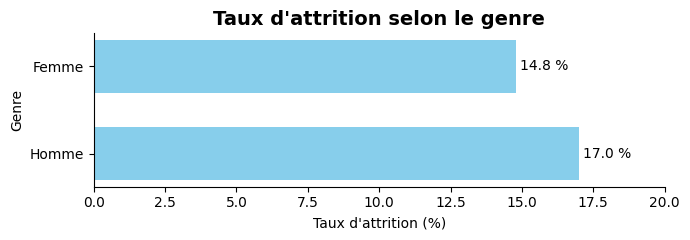

(None,)

In [34]:
fig , ax = plt.subplots(figsize=(7, 2.5))

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)

# Données

x = np.arange(len(pivot_genre_attrition.index))
y = pivot_genre_attrition["Yes"]

# barplot
bars = ax.barh(x, y, height=0.6, color="skyblue")

# Pourcentage affichés 

ax.bar_label(bars, labels=[f'{v :.1F} % ' for v in y], padding=3)

# Axes et labels
ax.set_yticks(x)
ax.set_yticklabels(pivot_genre_attrition.index)
ax.set_xlim(0, 20)

ax.set_xlabel("Taux d'attrition (%)")
ax.set_ylabel("Genre")
ax.set_title("Taux d'attrition selon le genre", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show(),

On observe que le taux d’attrition est légèrement plus élevé chez les **hommes** (≈17 %) que chez les **femmes** (≈15 %).  
L’écart reste toutefois modéré, suggérant une différence limitée entre les deux groupes.

Après avoir analysé la relation entre l’attrition et le genre, je m’intéresse maintenant au statut marital des employés.

#### 2.2.6 Attrition et statut marital
---

Dans cette section, je compare l’attrition selon le statut marital afin d’observer si le taux d’attrition varie en fonction de la situation familiale des employés.

##### Tableau de proportions

In [35]:
df_maritalStatut_attrition = df_vie_perso[["MaritalStatus", "Attrition"]]
df_maritalStatut_attrition.reset_index()
df_maritalStatut_attrition

# Calcul du groupe

maritalStatus_attrition = df_maritalStatut_attrition.groupby("MaritalStatus")["Attrition"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
maritalStatus_attrition = maritalStatus_attrition.reset_index(name="Pourcentage")
display(maritalStatus_attrition)

# Table pivot : ligne = MaritalStatut, colonne = Attrition , valeur = Pourcentage
pivot_maritalStatus_attrition = maritalStatus_attrition.pivot(index="MaritalStatus", columns="Attrition", values="Pourcentage")
pivot_maritalStatus_attrition = pivot_maritalStatus_attrition.sort_values("Yes", ascending=False)
pivot_maritalStatus_attrition

,MaritalStatus,Attrition,Pourcentage
0,Divorced,No,89.9
1,Married,No,87.5
2,Single,No,74.5
3,Single,Yes,25.5
4,Married,Yes,12.5
5,Divorced,Yes,10.1


Attrition,No,Yes
MaritalStatus,,
Single,74.5,25.5
Married,87.5,12.5
Divorced,89.9,10.1


##### Graphique — Analyse de la relation entre le statut marital et l’attrition

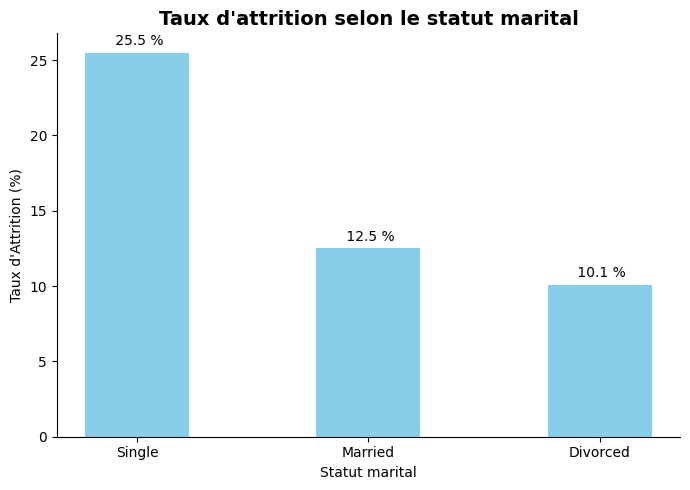

(None,)

In [36]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)

# Données

x = np.arange(len(pivot_maritalStatus_attrition.index))
y = pivot_maritalStatus_attrition["Yes"]

# barplot

bars = ax.bar(x, y, width=0.45, color="skyblue")

# Affiché poucentage

ax.bar_label(bars, labels=[f'{v : .1F} %' for v in y], padding=3)


# Axes et label
ax.set_xticks(x)
ax.set_xticklabels(pivot_maritalStatus_attrition.index)

ax.set_xlabel("Statut marital")
ax.set_ylabel("Taux d'Attrition (%)")
ax.set_title("Taux d'attrition selon le statut marital", fontsize=14, fontweight="bold")
fig.tight_layout()

plt.show(),

On observe que les employés ayant le statut **Single** présentent le taux d’attrition le plus élevé (≈26 %).  
À l’inverse, les statuts **Married** et **Divorced** affichent des taux d’attrition plus faibles, compris entre **10 % et 13 %**.


Après avoir analysé la relation entre l’attrition et le statut marital, je compare maintenant l’attrition selon la mobilité professionnelle, mesurée par le nombre d’entreprises précédemment travaillées.

#### 2.2.7 Attrition et mobilité professionnelle
---

Dans cette section, j’analyse la relation entre l’attrition et la mobilité professionnelle passée des employés, mesurée par le nombre d’entreprises précédemment travaillées, afin d’observer si le taux d’attrition varie selon le niveau de mobilité.

##### Tableau de proportions

In [37]:
df_NumCompaniesWorked_attrition = df_vie_perso[["Tranche_EtsTravaille","Attrition"]]
df_NumCompaniesWorked_attrition.reset_index()
df_NumCompaniesWorked_attrition

# Calcul du groupe
numCompaniesWorked_attrition = df_NumCompaniesWorked_attrition.groupby("Tranche_EtsTravaille",observed=True)["Attrition"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
numCompaniesWorked_attrition = numCompaniesWorked_attrition.reset_index(name="Pourcentage")
display(numCompaniesWorked_attrition)

# Table pivot ligne = Tranche_EtsTravaille, colonne = Attrition, valeur = Pourcentage

pivot_numCompaniesWorked_attrition = numCompaniesWorked_attrition.pivot(index="Tranche_EtsTravaille", columns="Attrition", values="Pourcentage")
pivot_numCompaniesWorked_attrition

,Tranche_EtsTravaille,Attrition,Pourcentage
0,2-3,No,89.5
1,0-1,No,83.1
2,4-6,No,82.0
3,+7,No,80.0
4,+7,Yes,20.0
5,4-6,Yes,18.0
6,0-1,Yes,16.9
7,2-3,Yes,10.5


Attrition,No,Yes
Tranche_EtsTravaille,,
0-1,83.1,16.9
2-3,89.5,10.5
4-6,82.0,18.0
+7,80.0,20.0


##### Graphique — Analyse de la relation entre la mobilité professionnelle et l’attrition

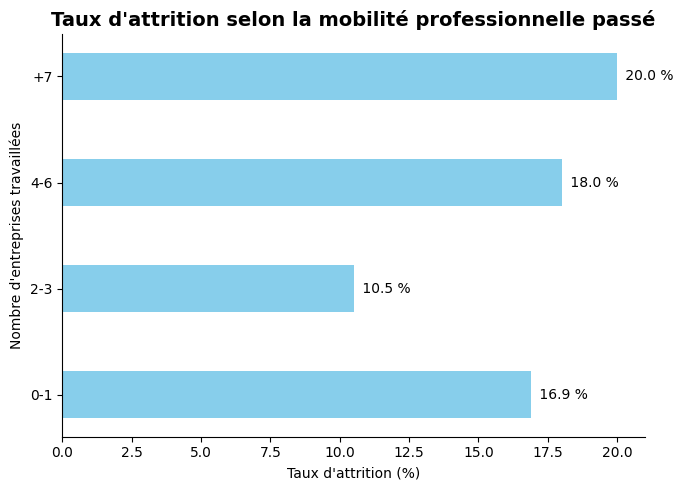

(None,)

In [38]:
fig, ax = plt.subplots(figsize=(7,5))

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

#  Données

x = np.arange(len(pivot_numCompaniesWorked_attrition.index))
y = pivot_numCompaniesWorked_attrition['Yes']

# Barplot

bars = ax.barh(x, y, height=0.45, color="skyblue")

# Affiché pourcentage

ax.bar_label(bars, labels=[f'{v : .1F} % 'for v in y], padding=3)

# Axes et labels

ax.set_yticks(x)
ax.set_yticklabels(pivot_numCompaniesWorked_attrition.index)

ax.set_xlabel("Taux d'attrition (%)")
ax.set_ylabel("Nombre d'entreprises travaillées")
ax.set_title("Taux d'attrition selon la mobilité professionnelle passé", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que les employés ayant travaillé dans **quatre entreprises ou plus** présentent des taux d’attrition plus élevés, compris entre **18 % et 20 %**, comparativement aux autres groupes..  

À l’inverse, les salariés ayant travaillé dans **deux à trois entreprises** affichent le taux d’attrition le plus faible (≈11 %).  

Les employés ayant travaillé dans **zéro ou une entreprise** présentent un niveau d’attrition intermédiaire, autour de **17 %**.


Une fois les comparaisons simples réalisées, j’explore les relations internes à l’axe afin d’identifier d’éventuels patterns ou corrélations.

## 3. Relations internes à l’axe Vie personnelle
----

### 3.1 Introduction

Après avoir analysé les relations entre les variables personnelles et l’attrition, cette section vise à explorer les relations internes entre les variables de l’axe *Vie personnelle*, afin d’identifier d’éventuels patterns ou profils récurrents.  
Les variables sont analysées à partir de tableaux croisés et de visualisations graphiques descriptives.

---


### 3.2 Analyse des relations entre variables personnelles
une courte phrase d’introduction

un tableau croisé

une visualisation simple

2–3 phrases d’observation factuelle

#### 3.2.1 Relation entre l’âge et la mobilité professionnelle
---

Dans cette partie, cette session vise à observer la relation entre la variable age et la variable mobilité professionnelle 

##### Tableaux croisés

In [39]:
age_numCompaniesWorked = df_vie_perso[["Tranche_Age", "Tranche_EtsTravaille"]]
age_numCompaniesWorked = age_numCompaniesWorked.reset_index()

age_numCompaniesWorked

# Calcul du groupe
df_age_numCompaniesWorked = age_numCompaniesWorked.groupby("Tranche_Age", observed=True)["Tranche_EtsTravaille"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
df_age_numCompaniesWorked = df_age_numCompaniesWorked.reset_index(name="Pourcentage")
display(df_age_numCompaniesWorked.head())

# Table pivot ligne = Tranche age, colonne = Tranche ets travaille , valeur = pourcentage
pivot_age_numCompaniesWorked = df_age_numCompaniesWorked.pivot_table(index="Tranche_Age", columns="Tranche_EtsTravaille", values="Pourcentage",observed=True)
pivot_age_numCompaniesWorked




,Tranche_Age,Tranche_EtsTravaille,Pourcentage
0,18-25,0-1,85.4
1,26-35,0-1,65.7
2,46-55,2-3,38.5
3,36-45,0-1,36.1
4,+55,4-6,31.9


Tranche_EtsTravaille,0-1,2-3,4-6,+7
Tranche_Age,,,,
18-25,85.4,7.3,4.9,2.4
26-35,65.7,13.0,12.5,8.7
36-45,36.1,25.0,25.2,13.7
46-55,17.3,38.5,25.2,19.0
+55,14.9,27.7,31.9,25.5


##### Visualisation

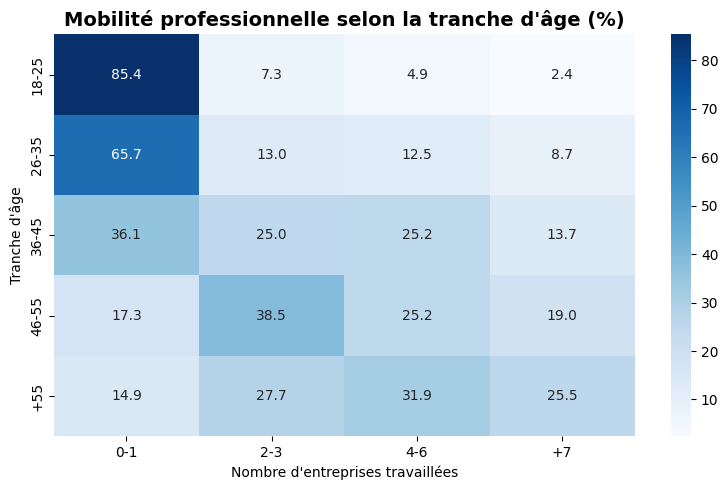

(None,)

In [40]:
# test heatmap

plt.figure(figsize=(8,5))
sns.heatmap(pivot_age_numCompaniesWorked, cmap="Blues", annot=True, fmt=".1f", cbar=True)
plt.gca().yaxis_inverted()
plt.title("Mobilité professionnelle selon la tranche d'âge (%)",fontsize=14, fontweight="bold" )
plt.xlabel("Nombre d'entreprises travaillées")
plt.ylabel("Tranche d'âge")
plt.xticks(rotation= 0)
plt.tight_layout()
plt.show(),

##### Observations descriptives

On observe que les employés âgés de **18–25 ans** et **26–35 ans** présentent majoritairement une mobilité professionnelle faible, avec une proportion élevée d’employés ayant travaillé dans **0 à 1 entreprise** (≈85 % et ≈66 %).  
Cette proportion diminue progressivement avec l’augmentation du nombre d’entreprises travaillées.

Pour la tranche **36–45 ans**, la mobilité reste plus répartie, bien que la catégorie **0–1 entreprise** demeure la plus représentée.

À l’inverse, les tranches d’âge **46–55 ans** et **+55 ans** présentent une mobilité professionnelle plus élevée.  
Chez les **46–55 ans**, la catégorie la plus fréquente correspond à **2–3 entreprises**, tandis que chez les **+55 ans**, la mobilité la plus représentée concerne **4–6 entreprises**.


Après avoir analysé la relation entre l’âge et la mobilité professionnelle, j’explore désormais le lien entre l’âge et le statut marital.

#### 3.2.2 Relation entre l’âge et le statut marital
---
Dans cette partie, cette session vise à observer la relation entre l’âge et le statut marital.

##### Tableaux croisés

In [41]:
age_maritalStatus = df_vie_perso[["Tranche_Age", "MaritalStatus"]]
age_maritalStatus.reset_index()

# Calcul du groupe
df_age_maritalStatus = age_maritalStatus.groupby("Tranche_Age")["MaritalStatus"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
df_age_maritalStatus = df_age_maritalStatus.reset_index(name="Pourcentage")
display(df_age_maritalStatus)

# Table pivot ligne = Tranche age, colonne = MaritalStatus, values = Pourcentage
pivot_age_maritalStatus = df_age_maritalStatus.pivot_table(index="Tranche_Age", columns="MaritalStatus", values="Pourcentage")
pivot_age_maritalStatus

C:\Users\Kemu\AppData\Local\Temp\ipykernel_34504\4077899971.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age_maritalStatus = age_maritalStatus.groupby("Tranche_Age")["MaritalStatus"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100


,Tranche_Age,MaritalStatus,Pourcentage
0,46-55,Married,51.8
1,18-25,Single,51.2
2,+55,Married,48.9
3,36-45,Married,47.0
4,26-35,Married,44.2
5,18-25,Married,36.6
6,26-35,Single,33.3
7,36-45,Single,28.4
8,46-55,Single,26.5
9,+55,Single,25.5


C:\Users\Kemu\AppData\Local\Temp\ipykernel_34504\4077899971.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_age_maritalStatus = df_age_maritalStatus.pivot_table(index="Tranche_Age", columns="MaritalStatus", values="Pourcentage")


MaritalStatus,Divorced,Married,Single
Tranche_Age,,,
18-25,12.2,36.6,51.2
26-35,22.4,44.2,33.3
36-45,24.6,47.0,28.4
46-55,21.7,51.8,26.5
+55,25.5,48.9,25.5


##### Visualisation

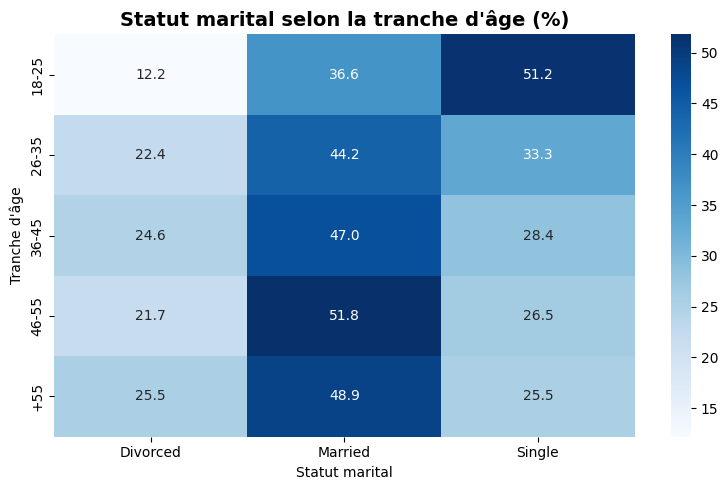

(None,)

In [42]:
# heatmap
plt.figure(figsize=(8,5))

sns.heatmap(pivot_age_maritalStatus, cmap="Blues", annot=True, fmt=".1F", cbar=True)
plt.gca().yaxis_inverted()

plt.xlabel("Statut marital")
plt.ylabel("Tranche d'âge")
plt.title("Statut marital selon la tranche d'âge (%)", fontsize=14, fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show(),

##### Observations descriptives
On observe que la proportion d’employés ayant le statut **Married** augmente avec l’âge.  
Ce statut est majoritaire chez les **46–55 ans** (≈52 %) et les **+55 ans** (≈49 %).

À l’inverse, le statut **Single** est principalement représenté chez les **18–25 ans**, où il concerne plus de la moitié des employés (≈51 %), puis diminue progressivement avec l’âge.

Le statut **Divorced** présente une répartition relativement stable pour les tranches d’âge intermédiaires (entre **22 % et 26 %**), mais reste peu représenté chez les **18–25 ans** (≈12 %).


Après avoir analysé la relation entre l’âge et le statut marital, j’explore désormais la relation entre la mobilité professionnelle et le statut marital.

#### 3.2.3 Relation entre la mobilité professionnelle et le statut marital
---
Dans cette section, j'observe la relation entre la mobilité professionnelle des employes et leur statut marital afin de completer les deux analyse précedentes et d'identifier certains parterns

##### Tableau croisé

In [43]:
numCompaniesWorked_maritalStatus = df_vie_perso[["MaritalStatus", "Tranche_EtsTravaille"]]
numCompaniesWorked_maritalStatus.reset_index()

# Calcul du groupe
df_NumCompaniesWorked_maritalStatus = numCompaniesWorked_maritalStatus.groupby('MaritalStatus')["Tranche_EtsTravaille"].value_counts(normalize=True).sort_values(ascending=False).round(3)*100
df_NumCompaniesWorked_maritalStatus =df_NumCompaniesWorked_maritalStatus.reset_index(name="Pourcentage")
display(df_NumCompaniesWorked_maritalStatus)

# Pivot table : ligne = Status marital, colonne = Nombre entreprise travaillés, valeur = Pourcentage
pivot_numCompaniesWorked_maritalStatus = df_NumCompaniesWorked_maritalStatus.pivot_table(index="MaritalStatus", columns="Tranche_EtsTravaille", values="Pourcentage")
pivot_numCompaniesWorked_maritalStatus

,MaritalStatus,Tranche_EtsTravaille,Pourcentage
0,Single,0-1,53.2
1,Married,0-1,48.0
2,Divorced,0-1,44.3
3,Divorced,4-6,22.3
4,Married,2-3,22.3
5,Divorced,2-3,21.1
6,Married,4-6,18.7
7,Single,2-3,18.3
8,Single,4-6,15.5
9,Single,+7,13.0


C:\Users\Kemu\AppData\Local\Temp\ipykernel_34504\1723501402.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_numCompaniesWorked_maritalStatus = df_NumCompaniesWorked_maritalStatus.pivot_table(index="MaritalStatus", columns="Tranche_EtsTravaille", values="Pourcentage")


Tranche_EtsTravaille,0-1,2-3,4-6,+7
MaritalStatus,,,,
Divorced,44.3,21.1,22.3,12.2
Married,48.0,22.3,18.7,11.0
Single,53.2,18.3,15.5,13.0


##### Visualisation

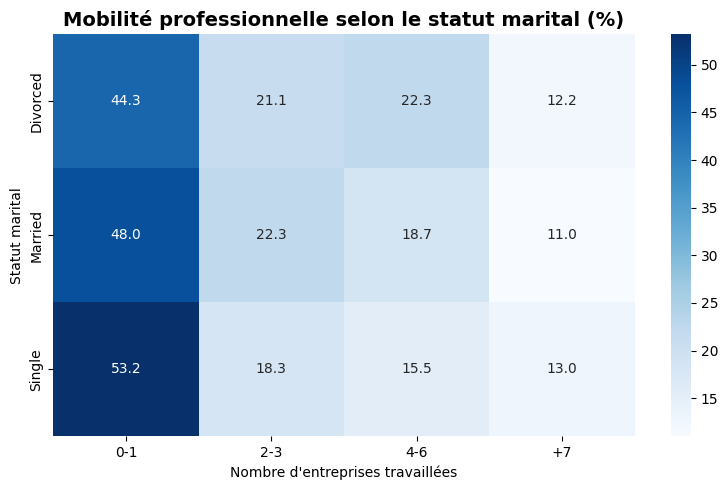

(None,)

In [44]:
# heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(pivot_numCompaniesWorked_maritalStatus, cmap="Blues", fmt=".1F", annot=True)
plt.gca().yaxis_inverted()
plt.title("Mobilité professionnelle selon le statut marital (%)", fontsize=14, fontweight="bold")
plt.xlabel("Nombre d'entreprises travaillées")
plt.ylabel("Statut marital")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show(),


##### Observations descriptives
On observe que, quel que soit le statut marital (**Single**, **Married** ou **Divorced**), les employés présentent majoritairement une mobilité professionnelle faible.  
La proportion d’employés ayant travaillé dans **0 à 1 entreprise** est élevée dans les trois groupes (≈53 %, ≈48 % et ≈44 %).

Cette proportion diminue progressivement avec l’augmentation du nombre d’entreprises précédemment travaillées, indiquant une structure de mobilité relativement similaire selon le statut marital.


Après avoir analysé ces trois relations, cette section synthétise les principaux patterns observés.

### 3.3 Synthèse des patterns observés
---
Les analyses des relations internes à l’axe *Vie personnelle* mettent en évidence plusieurs patterns structurants :

- **Pattern 1 - Relation entre l’âge et la mobilité professionnelle**  
  La mobilité professionnelle augmente globalement avec l’âge.  
  Les tranches d’âge les plus jeunes présentent majoritairement une faible mobilité (0 à 1 entreprise), tandis que les tranches plus âgées sont davantage représentées dans les catégories de mobilité plus élevée.  
  Ce pattern suggère une évolution progressive des parcours professionnels au fil du temps.

- **Pattern 2 - Relation entre l’âge et le statut marital**  
  Le statut marital varie fortement selon l’âge.  
  Les employés les plus jeunes sont majoritairement **Single**, tandis que la proportion d’employés **Married** augmente nettement avec l’âge.  
  Cette relation met en évidence des logiques de parcours de vie au sein de la population étudiée.

- **Pattern 3 - Relation entre la mobilité professionnelle et le statut marital**  
  La mobilité professionnelle présente une structure relativement similaire quel que soit le statut marital.  
  Dans l’ensemble des groupes (**Single**, **Married**, **Divorced**), la mobilité faible reste majoritaire, suggérant que le statut marital n’est pas associé à des différences marquées de mobilité professionnelle dans ce jeu de données.

Ces patterns permettent de mieux contextualiser les résultats observés précédemment et servent de base à la synthèse globale de l’axe Vie personnelle.

---

# 4. Résultats clés 
---


- **Âge**  
  Les employés âgés de **moins de 25 ans** présentent le **taux d’attrition le plus élevé**, alors même que leur **mobilité professionnelle est faible**.  
  À l’inverse, les tranches d’âge plus élevées affichent des taux d’attrition plus faibles, malgré une mobilité professionnelle plus importante.

- **Distance domicile–travail**  
  Le taux d’attrition tend à **augmenter avec la distance domicile–travail**.  
  Toutefois, la majorité des employés résident à proximité de leur lieu de travail, ce qui limite l’impact global de ce facteur dans la population étudiée.

- **Mobilité professionnelle**  
  Les employés ayant une **mobilité professionnelle élevée** présentent des **taux d’attrition plus importants** que ceux ayant une mobilité faible ou modérée.  
  Ces profils correspondent majoritairement à des tranches d’âge plus élevées.

- **Statut marital**  
  Les employés ayant le statut **Single** affichent un **taux d’attrition plus élevé** que les employés **Married** ou **Divorced**.  
  Cette difference est particulièrement marqué chez les **employés de moins de 25 ans**, où le statut Single est majoritaire.
---

# 5. Conclusion de l’axe “Vie personnelle”
---
L’étude de l’attrition doit donc être complétée par une analyse des **conditions de travail**, qui constituent des leviers d’action sur lesquels l’entreprise peut agir directement.Cet axe s’est concentré sur l’analyse des caractéristiques personnelles des employés (âge, genre, situation familiale, niveau et domaine d’éducation, distance domicile–travail, mobilité professionnelle).  
Ces facteurs individuels ne sont pas directement maîtrisables par l’entreprise, mais ils permettent de répondre à une première question descriptive essentielle : **qui quitte l’entreprise ?**

L’analyse des variables personnelles associées à l’attrition a permis de mettre en évidence que certains profils présentent des taux d’attrition plus élevés que d’autres, sans logique de stigmatisation individuelle.  
Certaines caractéristiques personnelles sont associées à des différences de taux d’attrition et contribuent à structurer des profils distincts au sein de la population étudiée.

Toutefois, l’analyse isolée de ces variables reste insuffisante sans prise en compte du contexte organisationnel.  
L’étude de l’attrition doit donc être complétée par une analyse des **conditions de travail**, qui constituent des leviers d’action sur lesquels l’entreprise peut agir directement.
